## Extrenal Data with noise -pinn with no ICs

---
We train a PINN for the three-body problem using noisy observations from the periodic Figure-8 orbit, without providing any initial conditions. The motivation for this setup stems from observations in previous experiments: when trained on sparse, high-noise data without prescribed initial conditions, PINNs often converge to solutions whose inferred initial conditions correspond to different periodic orbits. This behavior suggests that the network may exploit the underlying dynamical structure of the system and motivates further investigation into its ability to recover or identify periodic solutions.

* A softening parameter, eps = 10⁻⁹, is introduced in the gravitational interaction terms to prevent numerical singularities when two bodies approach very small separations.

* The output-layer biases are initialized to nonzero values to avoid the network producing trivial zero-valued predictions at t = 0.

* A fixed random seed is supplied to the weight initializer
  (initializer = tf.keras.initializers.GlorotNormal(seed=seed))
  to ensure deterministic network initialization and improve the reproducibility of training results.

#Training Procedure
---
1. Train the PINN using sparse noisy observational data without providing initial conditions.

2. Extract the initial conditions inferred by the trained network.

3. Use the inferred initial conditions as an initial guess in a least-squares optimization procedure to identify a nearby periodic orbit.
**Important:** The least-squares refinement requires a reasonable initial estimate of the orbit period. Poor period estimates can cause the optimization to fail or converge to nonphysical solutions, including zero or negative periods.

4. Integrate the equations of motion numerically using the refined initial conditions and validate the resulting orbit.

***Observation***: By varying the random seed used for network initialization, the PINN may converge to different solutions. In some cases, the inferred initial conditions lead, after least-squares refinement, to periodic orbits that do not belong to the Figure-8 family. This suggests that the training process can explore multiple regions of the solution space and may provide a mechanism for identifying distinct periodic three-body trajectories.



In [ ]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [ ]:
!pip install deepxde

In [ ]:
!pip install tensorflow tf_keras matplotlib numpy scipy

## IMPORTS

In [ ]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numpy.linalg import norm

# Training

Set the default float type to float64
SEED ===>  12
Compiling model...
'compile' took 0.000333 s



Model: "fnn_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (1, 64)                │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (1, 6)                 │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,838 (69.05 KB)

 Trainable params: 8,838 (69.05 KB)

 Non-trainable params: 0 (0.00 B)

old bias: [0. 0. 0. 0. 0. 0.]
new bias: [-0.2  0.2  0.   0.   0.2 -0.2]


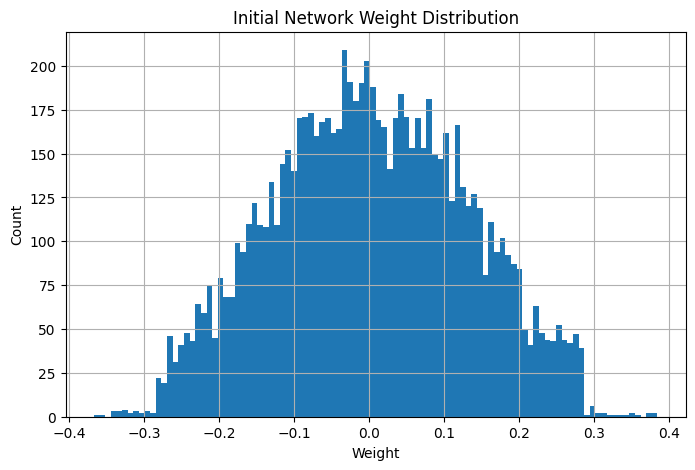

sum = 16.487843519984562
norm = 12.038738066023782
Training model...

Step      Train loss                                                                                                                  Test loss                                                                                                                   Test metric
0         [3.44e+01, 3.41e+01, 7.35e+01, 2.63e+02, 9.26e+01, 4.11e+02, 9.49e-01, 1.19e+00, 1.36e+00, 5.70e-02, 6.58e-01, 4.27e-01]    [2.60e+01, 2.56e+01, 7.92e+01, 3.13e+02, 8.99e+01, 4.72e+02, 9.49e-01, 1.19e+00, 1.36e+00, 5.70e-02, 6.58e-01, 4.27e-01]    []  
1000      [4.59e-02, 1.32e-01, 3.50e-01, 2.13e-01, 1.87e-01, 2.96e-01, 1.50e+00, 8.03e-01, 1.10e+00, 1.05e+00, 9.86e-01, 1.11e+00]    [4.27e-02, 1.50e-01, 4.17e-01, 9.39e-02, 2.20e-01, 2.95e-01, 1.50e+00, 8.03e-01, 1.10e+00, 1.05e+00, 9.86e-01, 1.11e+00]    []  
2000      [2.06e-02, 2.15e-02, 2.64e-02, 2.65e-02, 6.05e-03, 6.05e-02, 1.32e+00, 5.14e-01, 5.47e-01, 3.34e-01, 3.23e-01, 5.08e-01]    

In [ ]:



dde.config.set_default_float("float64")

seed=12
print("SEED ===> ",seed)
dde.config.set_random_seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# ============================================================
# Constants
# ============================================================
scale = 6.3259**(1/3)
G = 1.0
m = [1.0, 1.0, 1.0]
periods=1

endTime =periods *6.3259/scale**3


num_domain = 64
num_boundary = 12
num_test = 100


layer_size = [1] + [64]*3 + [6]
activation = "sin"
initializer =tf.keras.initializers.GlorotNormal(seed=seed)
#initializer ="Glorot normal" #"Glorot uniform" "Glorot normal"# "He normal" #

iterations =18000
learning_rate = 1e-3
loss_weights=[1]*6+[10]*6
optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001,weight_decay=0.004)


eps = 1e-9

# ============================================================
# Initial Conditions of figure-8 with rescaling - for numerical integrator only
# ============================================================
# positions
x1_0, y1_0 = -0.97000436/scale**2, 0.24308753/scale**2
x2_0, y2_0 =  0.97000436/scale**2, -0.24308753/scale**2
x3_0, y3_0 =  0.0/scale**2 ,0.0/scale**2

# velocities
vx1_0, vy1_0 = 0.4662036850*scale ,0.4323657300*scale
vx2_0, vy2_0 = 0.4662036850*scale, 0.4323657300*scale
vx3_0, vy3_0 = -0.93240737*scale, -0.86473146*scale


y0 = np.array([x1_0,y1_0,x2_0,y2_0,x3_0,y3_0])
v0 = np.array([vx1_0,vy1_0,vx2_0,vy2_0,vx3_0,vy3_0])

y0_tf = tf.constant(y0)
v0_tf = tf.constant(v0)

# ============================================================
# NUMERICAL SOLUTION (for synthetic measurements)
# ============================================================

def three_body_numeric(t, y):

    x1,y1,vx1,vy1,x2,y2,vx2,vy2,x3,y3,vx3,vy3 = y

    r12 = np.sqrt((x1-x2)**2 + (y1-y2)**2) + eps
    r13 = np.sqrt((x1-x3)**2 + (y1-y3)**2) + eps
    r23 = np.sqrt((x2-x3)**2 + (y2-y3)**2) + eps

    ax1 = G*(m[1]*(x2-x1)/r12**3 + m[2]*(x3-x1)/r13**3)
    ay1 = G*(m[1]*(y2-y1)/r12**3 + m[2]*(y3-y1)/r13**3)

    ax2 = G*(m[0]*(x1-x2)/r12**3 + m[2]*(x3-x2)/r23**3)
    ay2 = G*(m[0]*(y1-y2)/r12**3 + m[2]*(y3-y2)/r23**3)

    ax3 = G*(m[0]*(x1-x3)/r13**3 + m[1]*(x2-x3)/r23**3)
    ay3 = G*(m[0]*(y1-y3)/r13**3 + m[1]*(y2-y3)/r23**3)

    return [vx1,vy1,ax1,ay1,
            vx2,vy2,ax2,ay2,
            vx3,vy3,ax3,ay3]


t_span = (0,endTime)
t_eval = np.linspace(0,endTime,5000)

y0_full = [
x1_0,y1_0,vx1_0,vy1_0,
x2_0,y2_0,vx2_0,vy2_0,
x3_0,y3_0,vx3_0,vy3_0
]

sol = solve_ivp(three_body_numeric,t_span,y0_full,
                t_eval=t_eval,rtol=1e-10,atol=1e-12)

x1_n,y1_n = sol.y[0],sol.y[1]
x2_n,y2_n = sol.y[4],sol.y[5]
x3_n,y3_n = sol.y[8],sol.y[9]

# ============================================================
# SYNTHETIC NOISY MEASUREMENTS
# ============================================================

num_obs = 30
noise_level = 0.2

idx = np.sort(np.random.choice(len(t_eval),num_obs,replace=False))

t_obs = t_eval[idx][:,None]

y_obs_true = np.vstack([
x1_n[idx],y1_n[idx],
x2_n[idx],y2_n[idx],
x3_n[idx],y3_n[idx]
]).T

noise = noise_level*np.std(y_obs_true,axis=0)*np.random.randn(*y_obs_true.shape)

y_obs = y_obs_true + noise

# ============================================================
# PINN PDE
# ============================================================

def three_body_ode_second(t,y):

    x1,y1,x2,y2,x3,y3 = [y[:,i:i+1] for i in range(6)]

    r12 = tf.sqrt((x1-x2)**2 + (y1-y2)**2 )+eps
    r13 = tf.sqrt((x1-x3)**2 + (y1-y3)**2 )+eps
    r23 = tf.sqrt((x2-x3)**2 + (y2-y3)**2 )+eps

    ax1 = G*(m[1]*(x2-x1)/r12**3 + m[2]*(x3-x1)/r13**3)
    ay1 = G*(m[1]*(y2-y1)/r12**3 + m[2]*(y3-y1)/r13**3)

    ax2 = G*(m[0]*(x1-x2)/r12**3 + m[2]*(x3-x2)/r23**3)
    ay2 = G*(m[0]*(y1-y2)/r12**3 + m[2]*(y3-y2)/r23**3)

    ax3 = G*(m[0]*(x1-x3)/r13**3 + m[1]*(x2-x3)/r23**3)
    ay3 = G*(m[0]*(y1-y3)/r13**3 + m[1]*(y2-y3)/r23**3)

    x1_tt = dde.grad.hessian(y,t,component=0,i=0,j=0)
    y1_tt = dde.grad.hessian(y,t,component=1,i=0,j=0)
    x2_tt = dde.grad.hessian(y,t,component=2,i=0,j=0)
    y2_tt = dde.grad.hessian(y,t,component=3,i=0,j=0)
    x3_tt = dde.grad.hessian(y,t,component=4,i=0,j=0)
    y3_tt = dde.grad.hessian(y,t,component=5,i=0,j=0)

    return [
    (x1_tt-ax1),
    (y1_tt-ay1),
    (x2_tt-ax2),
    (y2_tt-ay2),
    (x3_tt-ax3),
    (y3_tt-ay3)
    ]

# ============================================================
# Geometry
# ============================================================

geom = dde.geometry.TimeDomain(0,endTime)

# observation constraints
observe_x1 = dde.PointSetBC(t_obs,y_obs[:,0:1],component=0)
observe_y1 = dde.PointSetBC(t_obs,y_obs[:,1:2],component=1)
observe_x2 = dde.PointSetBC(t_obs,y_obs[:,2:3],component=2)
observe_y2 = dde.PointSetBC(t_obs,y_obs[:,3:4],component=3)
observe_x3 = dde.PointSetBC(t_obs,y_obs[:,4:5],component=4)
observe_y3 = dde.PointSetBC(t_obs,y_obs[:,5:6],component=5)

data = dde.data.PDE(
geom,
three_body_ode_second,
[ observe_x1,observe_y1,observe_x2,observe_y2,observe_x3,observe_y3],
num_domain=num_domain,
num_boundary=num_boundary,
num_test=num_test
)

# ============================================================
# NETWORK
# ============================================================

net = dde.nn.FNN(layer_size,activation,initializer)


model = dde.Model(data,net)

model.compile(optimizer=optimizer,loss_weights=loss_weights)
#model.compile("adam",lr=learning_rate,loss_weights=loss_weights)

###############################################################
# Change bias in last layer to avoid zero outputs at t=0
###############################################################
model.predict([[0.0]])   #dummy predict to create model.. tensorflow behaviour
# modify bias
last_layer=3    #dependes on the number of layers layer 0 ,1,2,3 ....
model.net.summary()
last_layer = model.net.layers[last_layer]   # dense_3
w, b = last_layer.get_weights()
print("old bias:", b)
b = np.array([-0.2, 0.2, 0, 0, 0.2, -0.2])   # example separation
last_layer.set_weights([w, b])
print("new bias:", b)
##############################################################
##############################################################


# Output initial weight destribution

# Build network
model.predict([[0.0]])

# INITIAL WEIGHTS HISTOGRAM
all_weights = []

for layer in model.net.layers:

    w,b = layer.get_weights()

    all_weights.append(w.flatten())

all_weights = np.concatenate(all_weights)

plt.figure(figsize=(8,5))
plt.hist(all_weights,bins=100)
plt.title("Initial Network Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Count")
plt.grid(True)
plt.show()

#weights check
w_all = []

for layer in model.net.layers:
    w, b = layer.get_weights()
    w_all.append(w.flatten())

w_all = np.concatenate(w_all)

print("sum =", np.sum(w_all))
print("norm =", np.linalg.norm(w_all))

losshistory,train_state = model.train(iterations=iterations)

#model.compile("L-BFGS")
#losshistory,train_state = model.train()




# Plot training and test losses together with the PINN-predicted orbits

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


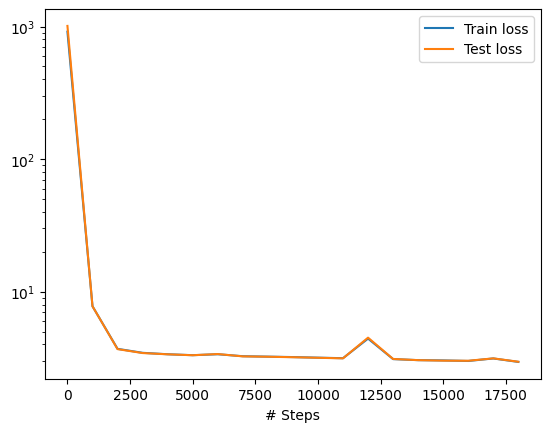

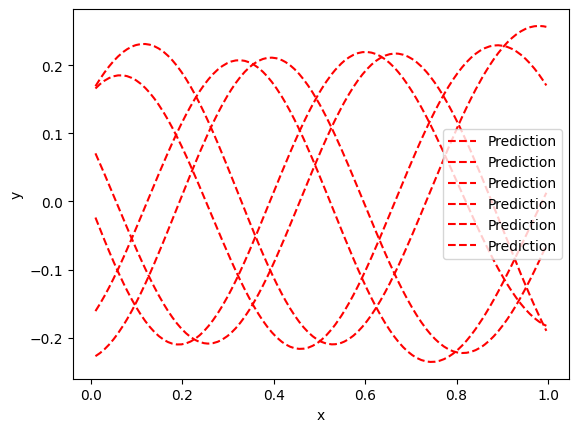

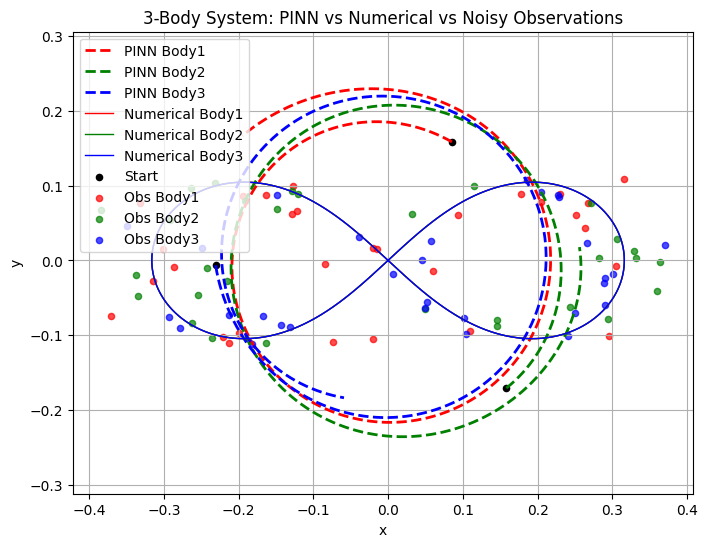

In [ ]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

# ============================================================
# PINN PREDICTION
# ============================================================

t_test = np.linspace(0,endTime,5000)[:,None]

y_pred = model.predict(t_test)

x1,y1 = y_pred[:,0],y_pred[:,1]
x2,y2 = y_pred[:,2],y_pred[:,3]
x3,y3 = y_pred[:,4],y_pred[:,5]

# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(x1,y1,'r--',lw=2,label="PINN Body1")
plt.plot(x2,y2,'g--',lw=2,label="PINN Body2")
plt.plot(x3,y3,'b--',lw=2,label="PINN Body3")

plt.plot(x1_n,y1_n,'r-',lw=1,label="Numerical Body1")
plt.plot(x2_n,y2_n,'g-',lw=1,label="Numerical Body2")
plt.plot(x3_n,y3_n,'b-',lw=1,label="Numerical Body3")

#starting points
plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=20, label='Start')

# noisy measurements
plt.scatter(y_obs[:,0],y_obs[:,1],c='red',s=20,alpha=0.7,label="Obs Body1")
plt.scatter(y_obs[:,2],y_obs[:,3],c='green',s=20,alpha=0.7,label="Obs Body2")
plt.scatter(y_obs[:,4],y_obs[:,5],c='blue',s=20,alpha=0.7,label="Obs Body3")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.axis("equal")

plt.title("3-Body System: PINN vs Numerical vs Noisy Observations")

plt.show()

##Use Automatic Differentiation (AD) to Compute Velocities and Extract the Initial Conditions Predicted by the PINN

In [ ]:
# ============================================================
# using autodiff for velocities
# ============================================================

#RESTORE endTime
endTime=1
t_test = np.linspace(0, endTime, 5000)[:, None]

# --- compute PINN positions + velocities with autodiff ---
t_tf = tf.convert_to_tensor(t_test)

with tf.GradientTape() as tape:
    tape.watch(t_tf)
    y_pred = model.net(t_tf)

# Jacobian gives derivatives of each output wrt time
dy_dt = tape.batch_jacobian(y_pred, t_tf)

# remove singleton dimension
dy_dt = dy_dt[:,:,0]

y_pred = y_pred.numpy()
dy_dt = dy_dt.numpy()

# PINN positions
x1, y1 = y_pred[:,0], y_pred[:,1]
x2, y2 = y_pred[:,2], y_pred[:,3]
x3, y3 = y_pred[:,4], y_pred[:,5]

# PINN velocities
vx1_p, vy1_p = dy_dt[:,0], dy_dt[:,1]
vx2_p, vy2_p = dy_dt[:,2], dy_dt[:,3]
vx3_p, vy3_p = dy_dt[:,4], dy_dt[:,5]


#print pinn inital conditions...
print("pinn inital conditions...")
print("               x0,      y0,      vx0  ,       vy0")
print("body_1    ", x1[0]," ",y1[0]," ",vx1_p[0]," ",vy1_p[0])
print("body_2    ", x2[0]," ",y2[0]," ",vx2_p[0]," ",vy2_p[0])
print("body_3    ", x3[0]," ",y3[0]," ",vx3_p[0]," ",vy3_p[0])

pinn inital conditions...
               x0,      y0,      vx0  ,       vy0
body_1     0.08542844405077071   0.15850919350384152   -1.4575667839843778   0.8245266380410132
body_2     0.15812122552001096   -0.1708306423136694   1.175702606539066   0.9296902872686197
body_3     -0.23067009004742411   -0.006527582510337665   0.2763933876425869   -1.7316317724309052


# Least-Squares Refinement of PINN-Predicted Initial Conditions

In [ ]:
#pinn ICs

y0 = np.array([
    x1[0], y1[0],
    x2[0], y2[0],
    x3[0], y3[0],

    vx1_p[0], vy1_p[0],
    vx2_p[0], vy2_p[0],
    vx3_p[0], vy3_p[0]
])


#function for least squares method

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import numpy as np

def refine_orbit(y0, T_guess, verbose=2):

    # --------------------------------
    # Three-body equations
    # --------------------------------
    def three_body(t, y):

        # y = [x1,y1,x2,y2,x3,y3,vx1,vy1,vx2,vy2,vx3,vy3]

        dydt = np.zeros_like(y)

        r = y[:6].reshape(3,2)
        v = y[6:].reshape(3,2)

        dydt[:6] = v.flatten()

        a = np.zeros((3,2))

        for i in range(3):
            for j in range(3):
                if i != j:
                    diff = r[j] - r[i]
                    dist = np.linalg.norm(diff)
                    a[i] += diff / dist**3

        dydt[6:] = a.flatten()

        return dydt

    # --------------------------------
    # Shooting residual
    # --------------------------------
    def shooting_error(vars):

        y0_new = vars[:-1]
        T = vars[-1]

        sol = solve_ivp(
            three_body,
            [0, T],
            y0_new,
            rtol=1e-9,
            atol=1e-9
        )

        yT = sol.y[:, -1]

        return yT - y0_new

    # --------------------------------
    # Least-squares optimization
    # --------------------------------
    vars0 = np.concatenate([y0, [T_guess]])

    result = least_squares(
        shooting_error,
        vars0,
        verbose=verbose,
        xtol=1e-10
    )

    y0_refined = result.x[:-1]
    T_refined = result.x[-1]

    error_norm = np.linalg.norm(
        shooting_error(result.x)
    )


    # --------------------------------
    # Print results
    # --------------------------------
    print("\n==============================")
    print("Least-Squares Refinement")
    print("==============================")

    print("Refined period:", T_refined)
    print("Error norm:", error_norm)

    print("\nRefined initial conditions:\n")

    labels = [
        "x1","y1","x2","y2","x3","y3",
        "vx1","vy1","vx2","vy2","vx3","vy3"
    ]

    for name, val in zip(labels, y0_refined):
        print(f"{name:>4} = {val:.16f}")

    print("==============================\n")

    return y0_refined, T_refined, error_norm, result

T_guess=3
y0_refined, T_refined, error_norm, result = refine_orbit(
    y0,
    T_guess=T_guess,verbose=2
)



   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.0131e+00                                    5.97e+03    
       1              3         2.2296e+00      4.78e+00       1.04e+00       1.20e+03    
       2              4         2.2001e+00      2.96e-02       2.08e+00       7.02e+02    
       3              5         2.1092e+00      9.09e-02       5.19e-01       3.01e+01    
       4              6         7.7863e-01      1.33e+00       1.30e-01       1.95e+01    
       5              8         4.4467e-01      3.34e-01       6.49e-02       1.56e+00    
       6              9         3.2803e-01      1.17e-01       1.30e-01       1.88e+01    
       7             10         3.1745e-01      1.06e-02       1.30e-01       2.66e+01    
       8             11         1.3719e-01      1.80e-01       3.25e-02       5.01e+00    
       9             12         1.2179e-01      1.54e-02       6.49e-02       1.36e+01    

# Orbit Obtained from the Least-Squares Refined Initial Conditions

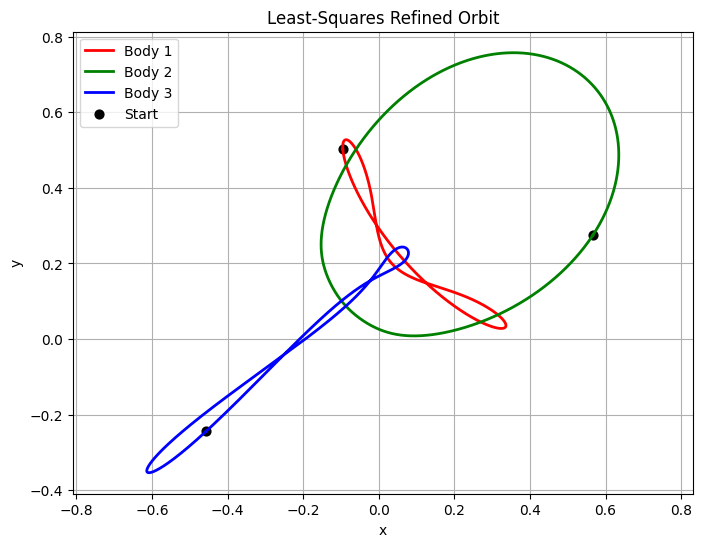

In [ ]:
y0_numeric = np.array([
    y0_refined[0],   # x1
    y0_refined[1],   # y1
    y0_refined[6],   # vx1
    y0_refined[7],   # vy1

    y0_refined[2],   # x2
    y0_refined[3],   # y2
    y0_refined[8],   # vx2
    y0_refined[9],   # vy2

    y0_refined[4],   # x3
    y0_refined[5],   # y3
    y0_refined[10],  # vx3
    y0_refined[11]   # vy3
])

sol = solve_ivp(
    three_body_numeric,
    [0, T_refined],
    y0_numeric,
    t_eval=np.linspace(0, T_refined, 5000),
    rtol=1e-10,
    atol=1e-12
)

# extract trajectories
x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]

# ============================================================
# Plot refined orbit
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(x1_n, y1_n, 'r-', lw=2, label='Body 1')
plt.plot(x2_n, y2_n, 'g-', lw=2, label='Body 2')
plt.plot(x3_n, y3_n, 'b-', lw=2, label='Body 3')

# starting points
plt.scatter(
    [x1_n[0], x2_n[0], x3_n[0]],
    [y1_n[0], y2_n[0], y3_n[0]],
    color='k',
    s=40,
    label='Start'
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Least-Squares Refined Orbit")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()